In [2]:
from splinetlsm.svi import SplineDynamicLSM
from splinetlsm.model_selection import select_knots
from splinetlsm.mcmc import dynamic_adjacency_to_vec
from splinetlsm.datasets import synthetic_network_mixture

## Exponential Covariance

In [4]:
n_nodes = 200
n_time_points = 100
Y, time_points, X, probas, Z, coefs, intercept, z = synthetic_network_mixture(
    n_nodes=n_nodes, n_time_points=n_time_points, n_features=2,
    ls_type='gp', include_covariates=True, tau=0.5, sigma=0.5,
    density=0.2, length_scale=0.2, random_state=0)

In [5]:
model = SplineDynamicLSM(
    n_features=6, n_segments='auto', alpha=0.95, 
    init_type='usvt', 
    random_state=4)

model.fit(Y, time_points, X,
        n_time_points=0.25, nonedge_proportion=2,
        step_size_power=0.75, step_size_delay=1, 
        tol=1e-3, max_iter=250)

Text(0.5, 0.98, 'Exponential')

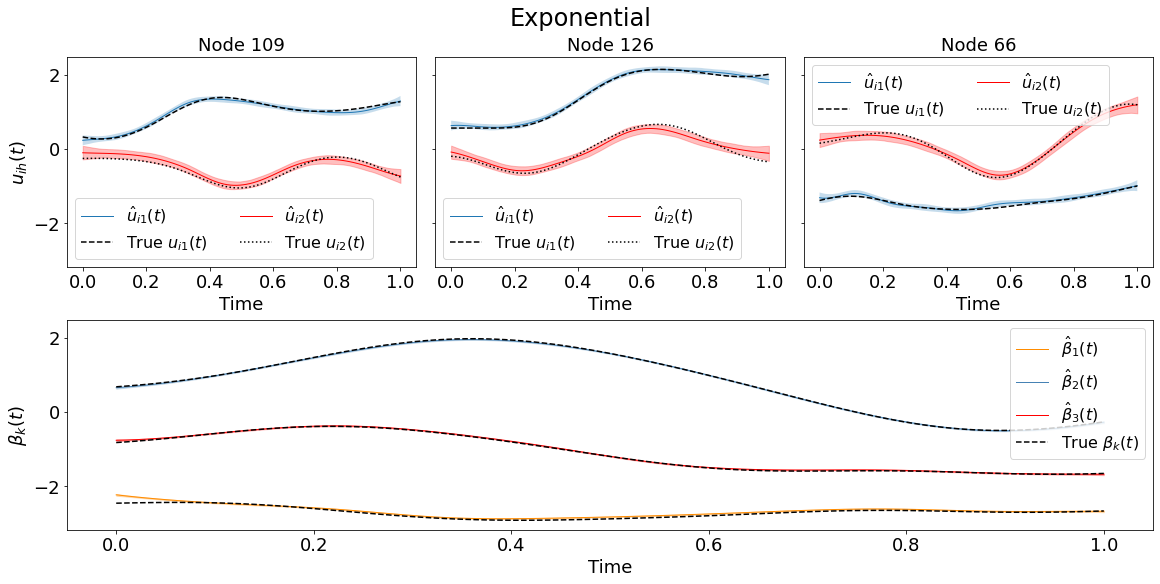

In [19]:
from scipy.linalg import orthogonal_procrustes

rng = np.random.RandomState(123)

ax = plt.figure(
    constrained_layout=True, figsize=(16, 8)).subplot_mosaic(
    """
    ABC
    DDD
    """, sharey=True
)

fontsize = 18

Z_true = Z.copy()
for t in range(len(Y)):
    R, _ = orthogonal_procrustes(Z_true[t], model.U_[..., :2][t])
    Z_true[t] = Z_true[t] @ R

keys = list(ax.keys())
for k, idx in enumerate(rng.choice(np.arange(Z_true.shape[1]), 3)):
    Z_est = model.samples_['W'][:, idx, 0] @ model.B_fit_.todense() 
    ci_svi = np.quantile(Z_est, q=[0.025, 0.975], axis=0)

    ax[keys[k]].plot(time_points, Z_est.mean(axis=0), linestyle='-', lw=1, label=r'$\hat{u}_{i1}(t)$')#, c='darkorange')
    ax[keys[k]].fill_between(time_points, ci_svi[0, :], ci_svi[1, :], alpha=0.25)#, color='darkorange')

    ax[keys[k]].plot(time_points, Z_true[:, idx, 0], 'k--', label=r'True $u_{i1}(t)$')

    Z_est = model.samples_['W'][:, idx, 1] @ model.B_fit_.todense() 
    ci_svi = np.quantile(Z_est, q=[0.025, 0.975], axis=0)

    ax[keys[k]].plot(time_points, Z_est.mean(axis=0), linestyle='-', lw=1, c='red', label=r'$\hat{u}_{i2}(t)$')
    ax[keys[k]].fill_between(time_points, ci_svi[0, :], ci_svi[1, :], alpha=0.25, color='red')
    
    ax[keys[k]].plot(time_points, Z_true[:, idx, 1], 'k:', label=r'True $u_{i2}(t)$')
    
    ax[keys[k]].set_xlabel('Time', fontsize=fontsize)
    if k == 0:
        ax[keys[k]].set_ylabel(r'$u_{ih}(t)$', fontsize=fontsize)
    ax[keys[k]].set_title(f'Node {idx}', fontsize=fontsize)
    ax[keys[k]].tick_params(axis='y', which='major', labelsize=fontsize)
    ax[keys[k]].tick_params(axis='x', which='major', labelsize=fontsize)
    ax[keys[k]].legend(fontsize=16, ncols=2)
    #ax[k].set_ylim(-2.5, 3.2)

ax = ax['D']
coef_est = model.samples_['W_intercept'] @ model.B_fit_.todense() 
ci_svi = np.quantile(coef_est, q=[0.025, 0.975], axis=0)

ax.plot(time_points, coef_est.mean(axis=0), linestyle='-', lw=1, c='darkorange', label=r'$\hat{\beta}_1(t)$')
ax.fill_between(time_points, ci_svi[0, :], ci_svi[1, :], alpha=0.25, color='darkorange')

coef_est = model.samples_['W_coefs'][:, 0] @ model.B_fit_.todense() 
ci_svi = np.quantile(coef_est, q=[0.025, 0.975], axis=0)

ax.plot(time_points, coef_est.mean(axis=0), linestyle='-', lw=1, c='steelblue', label=r'$\hat{\beta}_2(t)$')
ax.fill_between(time_points, ci_svi[0, :], ci_svi[1, :], alpha=0.25, color='steelblue')

coef_est = model.samples_['W_coefs'][:, 1] @ model.B_fit_.todense() 
ci_svi = np.quantile(coef_est, q=[0.025, 0.975], axis=0)

ax.plot(time_points, coef_est.mean(axis=0), linestyle='-', lw=1, c='red', label=r'$\hat{\beta}_3(t)$')
ax.fill_between(time_points, ci_svi[0, :], ci_svi[1, :], alpha=0.25, color='red')



ax.plot(time_points, intercept, 'k--', label = r'True $\beta_k(t)$')
ax.plot(time_points, coefs[:, 0], 'k--')
ax.plot(time_points, coefs[:, 1], 'k--')

ax.set_xlabel('Time', fontsize=fontsize)
ax.set_ylabel(r'$\beta_k(t)$', fontsize=fontsize)
ax.tick_params(axis='y', which='major', labelsize=fontsize)
ax.tick_params(axis='x', which='major', labelsize=fontsize)
ax.legend(fontsize=16)

plt.suptitle('Exponential', fontsize=24)
#plt.savefig('/Users/joshua/myworkspace/penalized-spline-lsm-vb/ba-submission/images/sim_examples_exp.png',
#            dpi=600, bbox_inches='tight')

## Matern($\nu = 2.5$)

In [20]:
n_nodes = 200
n_time_points = 100
Y, time_points, X, probas, Z, coefs, intercept, z = synthetic_network_mixture(
    n_nodes=n_nodes, n_time_points=n_time_points, n_features=2,
    ls_type='matern', include_covariates=True, tau=0.5, sigma=0.5,
    density=0.2, length_scale=0.2, random_state=0, nu=2.5)

In [21]:
model = SplineDynamicLSM(
    n_features=6, n_segments='auto', alpha=0.95, init_type='usvt', 
    random_state=4)

model.fit(Y, time_points, X,
        n_time_points=0.25, nonedge_proportion=2,
        step_size_power=0.75, step_size_delay=1, tol=1e-3,
        max_iter=250)

Text(0.5, 0.98, 'Matern($\\nu = 2.5$)')

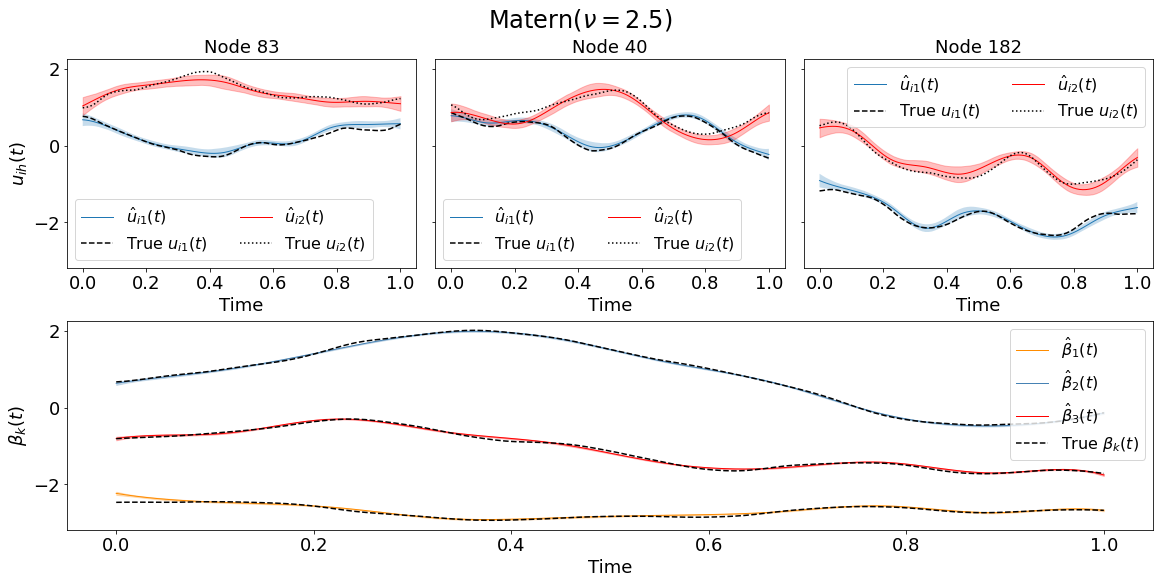

In [22]:
from scipy.linalg import orthogonal_procrustes

rng = np.random.RandomState(23)

ax = plt.figure(
    constrained_layout=True, figsize=(16, 8)).subplot_mosaic(
    """
    ABC
    DDD
    """, sharey=True
)

fontsize = 18

Z_true = Z.copy()
for t in range(len(Y)):
    R, _ = orthogonal_procrustes(Z_true[t], model.U_[..., :2][t])
    Z_true[t] = Z_true[t] @ R

keys = list(ax.keys())
for k, idx in enumerate(rng.choice(np.arange(Z_true.shape[1]), 3)):
    Z_est = model.samples_['W'][:, idx, 0] @ model.B_fit_.todense() 
    ci_svi = np.quantile(Z_est, q=[0.025, 0.975], axis=0)

    ax[keys[k]].plot(time_points, Z_est.mean(axis=0), linestyle='-', lw=1, label=r'$\hat{u}_{i1}(t)$')#, c='darkorange')
    ax[keys[k]].fill_between(time_points, ci_svi[0, :], ci_svi[1, :], alpha=0.25)#, color='darkorange')

    ax[keys[k]].plot(time_points, Z_true[:, idx, 0], 'k--', label=r'True $u_{i1}(t)$')

    Z_est = model.samples_['W'][:, idx, 1] @ model.B_fit_.todense() 
    ci_svi = np.quantile(Z_est, q=[0.025, 0.975], axis=0)

    ax[keys[k]].plot(time_points, Z_est.mean(axis=0), linestyle='-', lw=1, c='red', label=r'$\hat{u}_{i2}(t)$')
    ax[keys[k]].fill_between(time_points, ci_svi[0, :], ci_svi[1, :], alpha=0.25, color='red')
    
    ax[keys[k]].plot(time_points, Z_true[:, idx, 1], 'k:', label=r'True $u_{i2}(t)$')
    
    ax[keys[k]].set_xlabel('Time', fontsize=fontsize)
    if k == 0:
        ax[keys[k]].set_ylabel(r'$u_{ih}(t)$', fontsize=fontsize)
    ax[keys[k]].set_title(f'Node {idx}', fontsize=fontsize)
    ax[keys[k]].tick_params(axis='y', which='major', labelsize=fontsize)
    ax[keys[k]].tick_params(axis='x', which='major', labelsize=fontsize)
    ax[keys[k]].legend(fontsize=16, ncols=2)
    #ax[k].set_ylim(-2.5, 3.2)

ax = ax['D']
coef_est = model.samples_['W_intercept'] @ model.B_fit_.todense() 
ci_svi = np.quantile(coef_est, q=[0.025, 0.975], axis=0)

ax.plot(time_points, coef_est.mean(axis=0), linestyle='-', lw=1, c='darkorange', label=r'$\hat{\beta}_1(t)$')
ax.fill_between(time_points, ci_svi[0, :], ci_svi[1, :], alpha=0.25, color='darkorange')

coef_est = model.samples_['W_coefs'][:, 0] @ model.B_fit_.todense() 
ci_svi = np.quantile(coef_est, q=[0.025, 0.975], axis=0)

ax.plot(time_points, coef_est.mean(axis=0), linestyle='-', lw=1, c='steelblue', label=r'$\hat{\beta}_2(t)$')
ax.fill_between(time_points, ci_svi[0, :], ci_svi[1, :], alpha=0.25, color='steelblue')

coef_est = model.samples_['W_coefs'][:, 1] @ model.B_fit_.todense() 
ci_svi = np.quantile(coef_est, q=[0.025, 0.975], axis=0)

ax.plot(time_points, coef_est.mean(axis=0), linestyle='-', lw=1, c='red', label=r'$\hat{\beta}_3(t)$')
ax.fill_between(time_points, ci_svi[0, :], ci_svi[1, :], alpha=0.25, color='red')



ax.plot(time_points, intercept, 'k--', label = r'True $\beta_k(t)$')
ax.plot(time_points, coefs[:, 0], 'k--')
ax.plot(time_points, coefs[:, 1], 'k--')

ax.set_xlabel('Time', fontsize=fontsize)
ax.set_ylabel(r'$\beta_k(t)$', fontsize=fontsize)
ax.tick_params(axis='y', which='major', labelsize=fontsize)
ax.tick_params(axis='x', which='major', labelsize=fontsize)
ax.legend(fontsize=16)

plt.suptitle(r'Matern($\nu = 2.5$)', fontsize=24)
plt.savefig('/Users/joshua/myworkspace/penalized-spline-lsm-vb/ba-submission/images/sim_examples_nu25.png',
            dpi=600, bbox_inches='tight')

## Matern($\nu = 1.5$)

In [5]:
n_nodes = 200
n_time_points = 100
Y, time_points, X, probas, Z, coefs, intercept, z = synthetic_network_mixture(
    n_nodes=n_nodes, n_time_points=n_time_points, n_features=2,
    ls_type='matern', include_covariates=True, tau=0.5, sigma=0.5,
    density=0.2, length_scale=0.2, random_state=0, nu=1.5)

0.20017989
Best AUC: 0.902


In [6]:
model = SplineDynamicLSM(
    n_features=6, n_segments='auto', alpha=0.95, init_type='usvt', 
    random_state=5)

model.fit(Y, time_points, X,
        n_time_points=0.25, nonedge_proportion=2,
        step_size_power=0.75, step_size_delay=1, tol=1e-3,
        max_iter=250)

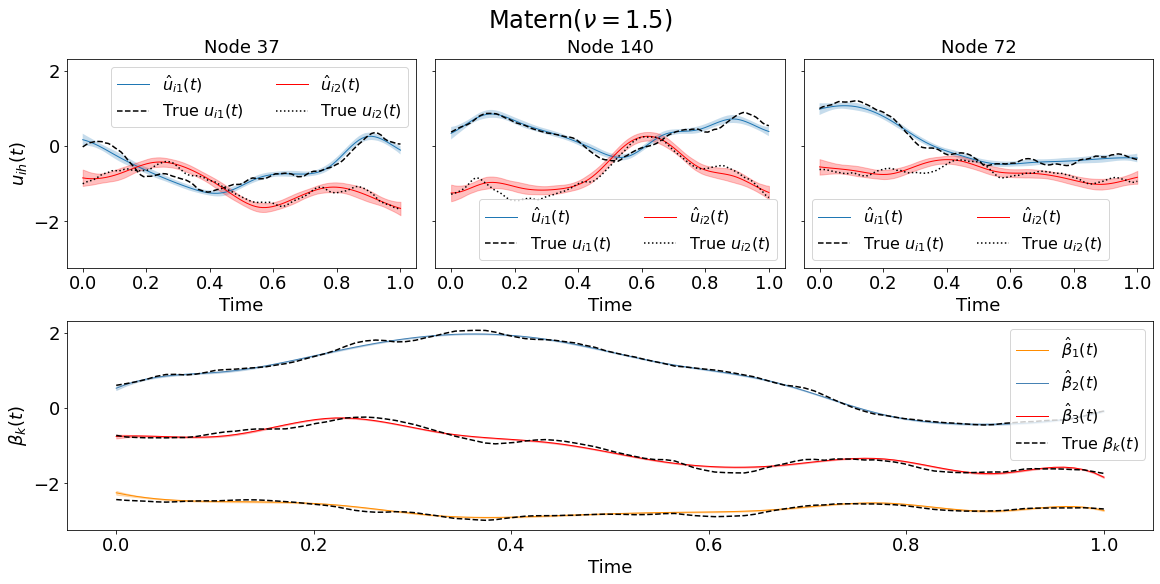

In [9]:
from scipy.linalg import orthogonal_procrustes

rng = np.random.RandomState(1)

ax = plt.figure(
    constrained_layout=True, figsize=(16, 8)).subplot_mosaic(
    """
    ABC
    DDD
    """, sharey=True
)

fontsize = 18

Z_true = Z.copy()
for t in range(len(Y)):
    R, _ = orthogonal_procrustes(Z_true[t], model.U_[..., :2][t])
    Z_true[t] = Z_true[t] @ R

keys = list(ax.keys())
for k, idx in enumerate(rng.choice(np.arange(Z_true.shape[1]), 3)):
    Z_est = model.samples_['W'][:, idx, 0] @ model.B_fit_.todense() 
    ci_svi = np.quantile(Z_est, q=[0.025, 0.975], axis=0)

    ax[keys[k]].plot(time_points, Z_est.mean(axis=0), linestyle='-', lw=1, label=r'$\hat{u}_{i1}(t)$')#, c='darkorange')
    ax[keys[k]].fill_between(time_points, ci_svi[0, :], ci_svi[1, :], alpha=0.25)#, color='darkorange')

    ax[keys[k]].plot(time_points, Z_true[:, idx, 0], 'k--', label=r'True $u_{i1}(t)$')

    Z_est = model.samples_['W'][:, idx, 1] @ model.B_fit_.todense() 
    ci_svi = np.quantile(Z_est, q=[0.025, 0.975], axis=0)

    ax[keys[k]].plot(time_points, Z_est.mean(axis=0), linestyle='-', lw=1, c='red', label=r'$\hat{u}_{i2}(t)$')
    ax[keys[k]].fill_between(time_points, ci_svi[0, :], ci_svi[1, :], alpha=0.25, color='red')
    
    ax[keys[k]].plot(time_points, Z_true[:, idx, 1], 'k:', label=r'True $u_{i2}(t)$')
    
    ax[keys[k]].set_xlabel('Time', fontsize=fontsize)
    if k == 0:
        ax[keys[k]].set_ylabel(r'$u_{ih}(t)$', fontsize=fontsize)
    ax[keys[k]].set_title(f'Node {idx}', fontsize=fontsize)
    ax[keys[k]].tick_params(axis='y', which='major', labelsize=fontsize)
    ax[keys[k]].tick_params(axis='x', which='major', labelsize=fontsize)
    ax[keys[k]].legend(fontsize=16, ncols=2)
    #ax[k].set_ylim(-2.5, 3.2)

ax = ax['D']
coef_est = model.samples_['W_intercept'] @ model.B_fit_.todense() 
ci_svi = np.quantile(coef_est, q=[0.025, 0.975], axis=0)

ax.plot(time_points, coef_est.mean(axis=0), linestyle='-', lw=1, c='darkorange', label=r'$\hat{\beta}_1(t)$')
ax.fill_between(time_points, ci_svi[0, :], ci_svi[1, :], alpha=0.25, color='darkorange')

coef_est = model.samples_['W_coefs'][:, 0] @ model.B_fit_.todense() 
ci_svi = np.quantile(coef_est, q=[0.025, 0.975], axis=0)

ax.plot(time_points, coef_est.mean(axis=0), linestyle='-', lw=1, c='steelblue', label=r'$\hat{\beta}_2(t)$')
ax.fill_between(time_points, ci_svi[0, :], ci_svi[1, :], alpha=0.25, color='steelblue')

coef_est = model.samples_['W_coefs'][:, 1] @ model.B_fit_.todense() 
ci_svi = np.quantile(coef_est, q=[0.025, 0.975], axis=0)

ax.plot(time_points, coef_est.mean(axis=0), linestyle='-', lw=1, c='red', label=r'$\hat{\beta}_3(t)$')
ax.fill_between(time_points, ci_svi[0, :], ci_svi[1, :], alpha=0.25, color='red')



ax.plot(time_points, intercept, 'k--', label = r'True $\beta_k(t)$')
ax.plot(time_points, coefs[:, 0], 'k--')
ax.plot(time_points, coefs[:, 1], 'k--')

ax.set_xlabel('Time', fontsize=fontsize)
ax.set_ylabel(r'$\beta_k(t)$', fontsize=fontsize)
ax.tick_params(axis='y', which='major', labelsize=fontsize)
ax.tick_params(axis='x', which='major', labelsize=fontsize)
ax.legend(fontsize=16)
    
plt.suptitle(r'Matern($\nu = 1.5$)', fontsize=24)
plt.savefig('/Users/joshua/myworkspace/penalized-spline-lsm-vb/ba-submission/images/sim_examples_nu15_default.png',
            dpi=600, bbox_inches='tight')

## Matern($\nu = 0.5$)

In [2]:
n_nodes = 200
n_time_points = 100
Y, time_points, X, probas, Z, coefs, intercept, z = synthetic_network_mixture(
    n_nodes=n_nodes, n_time_points=n_time_points, n_features=2,
    ls_type='matern', include_covariates=True, tau=0.5, sigma=0.5,
    density=0.2, length_scale=0.2, random_state=0, nu=0.5)

0.20021003
Best AUC: 0.901


## Untuned $\ell$

In [7]:
model = SplineDynamicLSM(
    n_features=6, n_segments='auto', alpha=0.95, init_type='usvt', 
    random_state=5)

model.fit(Y, time_points, X,
        n_time_points=0.25, nonedge_proportion=2,
        step_size_power=0.75, step_size_delay=1, tol=1e-3,
        max_iter=250)

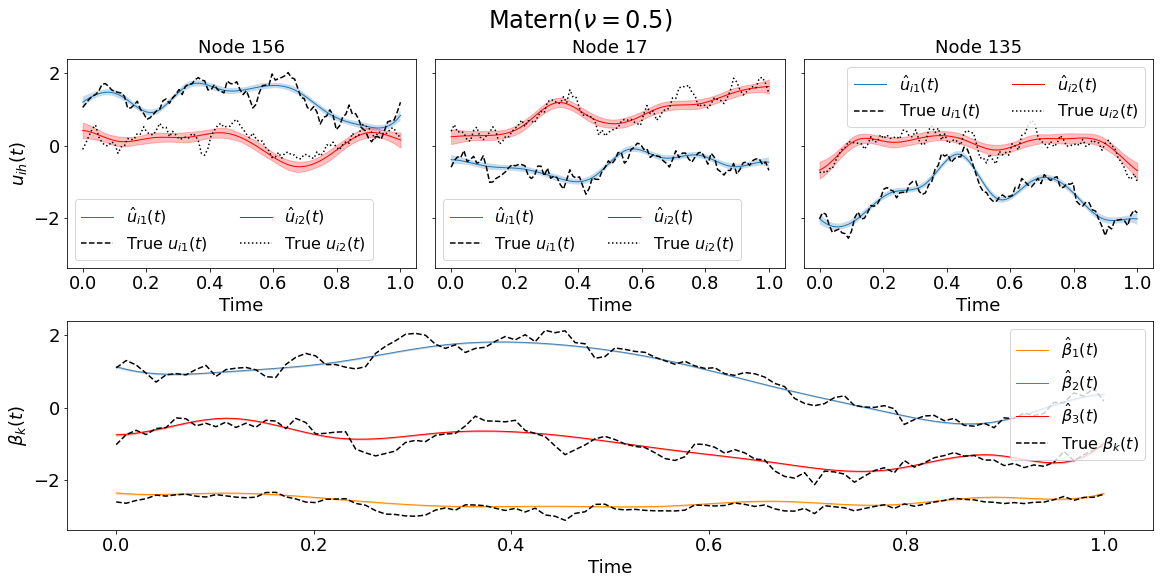

In [17]:
from scipy.linalg import orthogonal_procrustes

rng = np.random.RandomState(124)

ax = plt.figure(
    constrained_layout=True, figsize=(16, 8)).subplot_mosaic(
    """
    ABC
    DDD
    """, sharey=True
)

fontsize = 18

Z_true = Z.copy()
for t in range(len(Y)):
    R, _ = orthogonal_procrustes(Z_true[t], model.U_[..., :2][t])
    Z_true[t] = Z_true[t] @ R

keys = list(ax.keys())
for k, idx in enumerate(rng.choice(np.arange(Z_true.shape[1]), 3)):
    Z_est = model.samples_['W'][:, idx, 0] @ model.B_fit_.todense() 
    ci_svi = np.quantile(Z_est, q=[0.025, 0.975], axis=0)

    ax[keys[k]].plot(time_points, Z_est.mean(axis=0), linestyle='-', lw=1, label=r'$\hat{u}_{i1}(t)$')#, c='darkorange')
    ax[keys[k]].fill_between(time_points, ci_svi[0, :], ci_svi[1, :], alpha=0.25)#, color='darkorange')

    ax[keys[k]].plot(time_points, Z_true[:, idx, 0], 'k--', label=r'True $u_{i1}(t)$')

    Z_est = model.samples_['W'][:, idx, 1] @ model.B_fit_.todense() 
    ci_svi = np.quantile(Z_est, q=[0.025, 0.975], axis=0)

    ax[keys[k]].plot(time_points, Z_est.mean(axis=0), linestyle='-', lw=1, c='red', label=r'$\hat{u}_{i2}(t)$')
    ax[keys[k]].fill_between(time_points, ci_svi[0, :], ci_svi[1, :], alpha=0.25, color='red')
    
    ax[keys[k]].plot(time_points, Z_true[:, idx, 1], 'k:', label=r'True $u_{i2}(t)$')
    
    ax[keys[k]].set_xlabel('Time', fontsize=fontsize)
    if k == 0:
        ax[keys[k]].set_ylabel(r'$u_{ih}(t)$', fontsize=fontsize)
    ax[keys[k]].set_title(f'Node {idx}', fontsize=fontsize)
    ax[keys[k]].tick_params(axis='y', which='major', labelsize=fontsize)
    ax[keys[k]].tick_params(axis='x', which='major', labelsize=fontsize)
    ax[keys[k]].legend(fontsize=16, ncols=2)
    #ax[k].set_ylim(-2.5, 3.2)

ax = ax['D']
coef_est = model.samples_['W_intercept'] @ model.B_fit_.todense() 
ci_svi = np.quantile(coef_est, q=[0.025, 0.975], axis=0)

ax.plot(time_points, coef_est.mean(axis=0), linestyle='-', lw=1, c='darkorange', label=r'$\hat{\beta}_1(t)$')
ax.fill_between(time_points, ci_svi[0, :], ci_svi[1, :], alpha=0.25, color='darkorange')

coef_est = model.samples_['W_coefs'][:, 0] @ model.B_fit_.todense() 
ci_svi = np.quantile(coef_est, q=[0.025, 0.975], axis=0)

ax.plot(time_points, coef_est.mean(axis=0), linestyle='-', lw=1, c='steelblue', label=r'$\hat{\beta}_2(t)$')
ax.fill_between(time_points, ci_svi[0, :], ci_svi[1, :], alpha=0.25, color='steelblue')

coef_est = model.samples_['W_coefs'][:, 1] @ model.B_fit_.todense() 
ci_svi = np.quantile(coef_est, q=[0.025, 0.975], axis=0)

ax.plot(time_points, coef_est.mean(axis=0), linestyle='-', lw=1, c='red', label=r'$\hat{\beta}_3(t)$')
ax.fill_between(time_points, ci_svi[0, :], ci_svi[1, :], alpha=0.25, color='red')



ax.plot(time_points, intercept, 'k--', label = r'True $\beta_k(t)$')
ax.plot(time_points, coefs[:, 0], 'k--')
ax.plot(time_points, coefs[:, 1], 'k--')

ax.set_xlabel('Time', fontsize=fontsize)
ax.set_ylabel(r'$\beta_k(t)$', fontsize=fontsize)
ax.tick_params(axis='y', which='major', labelsize=fontsize)
ax.tick_params(axis='x', which='major', labelsize=fontsize)
ax.legend(fontsize=16)
    

plt.suptitle(r'Matern($\nu = 0.5$)', fontsize=24)
plt.savefig('/Users/joshua/myworkspace/penalized-spline-lsm-vb/ba-submission/images/sim_examples_nu05_default.png',
            dpi=600, bbox_inches='tight')

## Tuned $\ell$

In [3]:
model_tuned = SplineDynamicLSM(
    n_features=6, n_segments='auto', alpha=0.95, init_type='usvt', 
    random_state=5, n_knots_scale_factor=7)

model_tuned.fit(Y, time_points, X,
        n_time_points=0.25, nonedge_proportion=2,
        step_size_power=0.75, step_size_delay=1, tol=1e-3,
        max_iter=250)

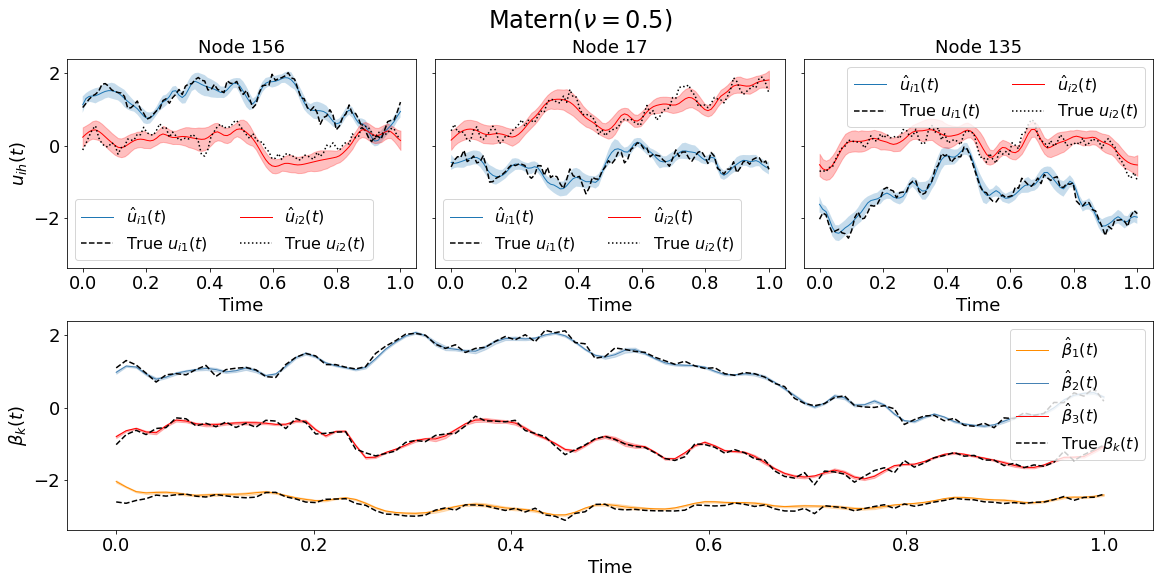

In [4]:
from scipy.linalg import orthogonal_procrustes

rng = np.random.RandomState(124)

ax = plt.figure(
    constrained_layout=True, figsize=(16, 8)).subplot_mosaic(
    """
    ABC
    DDD
    """, sharey=True
)

fontsize = 18

Z_true = Z.copy()
for t in range(len(Y)):
    R, _ = orthogonal_procrustes(Z_true[t], model_tuned.U_[..., :2][t])
    Z_true[t] = Z_true[t] @ R

keys = list(ax.keys())
for k, idx in enumerate(rng.choice(np.arange(Z_true.shape[1]), 3)):
    Z_est = model_tuned.samples_['W'][:, idx, 0] @ model_tuned.B_fit_.todense() 
    ci_svi = np.quantile(Z_est, q=[0.025, 0.975], axis=0)

    ax[keys[k]].plot(time_points, Z_est.mean(axis=0), linestyle='-', lw=1, label=r'$\hat{u}_{i1}(t)$')#, c='darkorange')
    ax[keys[k]].fill_between(time_points, ci_svi[0, :], ci_svi[1, :], alpha=0.25)#, color='darkorange')

    ax[keys[k]].plot(time_points, Z_true[:, idx, 0], 'k--', label=r'True $u_{i1}(t)$')

    Z_est = model_tuned.samples_['W'][:, idx, 1] @ model_tuned.B_fit_.todense() 
    ci_svi = np.quantile(Z_est, q=[0.025, 0.975], axis=0)

    ax[keys[k]].plot(time_points, Z_est.mean(axis=0), linestyle='-', lw=1, c='red', label=r'$\hat{u}_{i2}(t)$')
    ax[keys[k]].fill_between(time_points, ci_svi[0, :], ci_svi[1, :], alpha=0.25, color='red')
    
    ax[keys[k]].plot(time_points, Z_true[:, idx, 1], 'k:', label=r'True $u_{i2}(t)$')
    
    ax[keys[k]].set_xlabel('Time', fontsize=fontsize)
    if k == 0:
        ax[keys[k]].set_ylabel(r'$u_{ih}(t)$', fontsize=fontsize)
    ax[keys[k]].set_title(f'Node {idx}', fontsize=fontsize)
    ax[keys[k]].tick_params(axis='y', which='major', labelsize=fontsize)
    ax[keys[k]].tick_params(axis='x', which='major', labelsize=fontsize)
    ax[keys[k]].legend(fontsize=16, ncols=2)
    #ax[k].set_ylim(-2.5, 3.2)

ax = ax['D']
coef_est = model_tuned.samples_['W_intercept'] @ model_tuned.B_fit_.todense() 
ci_svi = np.quantile(coef_est, q=[0.025, 0.975], axis=0)

ax.plot(time_points, coef_est.mean(axis=0), linestyle='-', lw=1, c='darkorange', label=r'$\hat{\beta}_1(t)$')
ax.fill_between(time_points, ci_svi[0, :], ci_svi[1, :], alpha=0.25, color='darkorange')

coef_est = model_tuned.samples_['W_coefs'][:, 0] @ model_tuned.B_fit_.todense() 
ci_svi = np.quantile(coef_est, q=[0.025, 0.975], axis=0)

ax.plot(time_points, coef_est.mean(axis=0), linestyle='-', lw=1, c='steelblue', label=r'$\hat{\beta}_2(t)$')
ax.fill_between(time_points, ci_svi[0, :], ci_svi[1, :], alpha=0.25, color='steelblue')

coef_est = model_tuned.samples_['W_coefs'][:, 1] @ model_tuned.B_fit_.todense() 
ci_svi = np.quantile(coef_est, q=[0.025, 0.975], axis=0)

ax.plot(time_points, coef_est.mean(axis=0), linestyle='-', lw=1, c='red', label=r'$\hat{\beta}_3(t)$')
ax.fill_between(time_points, ci_svi[0, :], ci_svi[1, :], alpha=0.25, color='red')



ax.plot(time_points, intercept, 'k--', label = r'True $\beta_k(t)$')
ax.plot(time_points, coefs[:, 0], 'k--')
ax.plot(time_points, coefs[:, 1], 'k--')

ax.set_xlabel('Time', fontsize=fontsize)
ax.set_ylabel(r'$\beta_k(t)$', fontsize=fontsize)
ax.tick_params(axis='y', which='major', labelsize=fontsize)
ax.tick_params(axis='x', which='major', labelsize=fontsize)
ax.legend(fontsize=16)

plt.suptitle(r'Matern($\nu = 0.5$)', fontsize=24)
plt.savefig('/Users/joshua/myworkspace/penalized-spline-lsm-vb/ba-submission/images/sim_examples_nu05_tuned.png',
            dpi=600, bbox_inches='tight')